In [1]:
library(forecast)

Warning message:
"package 'forecast' was built under R version 4.5.2"
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



# Load cleaned data

In [2]:
unemp <- read.csv("eda_data.csv")
tail(unemp)

,month,unemployment_rate,total_employment,all_gdp
,<chr>,<dbl>,<dbl>,<int>
343,2025-07-01,6.9,21206.7,2337520
344,2025-08-01,7.1,21086.3,2336252
345,2025-09-01,7.1,21039.4,2339856
346,2025-10-01,6.9,21125.7,2332992
347,2025-11-01,6.6,21117.8,2333414
348,2025-12-01,6.8,21056.4,2339127


In [ ]:
unemp_ts <- ts(unemp$unemployment_rate, start = c(1997, 1), frequency = 12)

# Use log of gdp as it's an economic indicator
unemp$log_gdp <- log(unemp$all_gdp)

# unemp$diff_emp <- c(NA, diff(unemp$total_employment))

In [77]:
cor(unemp$log_gdp,unemp$total_employment)

[1] 0.9821454

The high correlation rate between log_gdp and total_employment means we can chose to ignore total_employment to train models faster.

In [ ]:
xreg_ts <- ts(unemp[, c("log_gdp")],
              start = c(1997, 1), frequency = 12)


# Test/Train split

In [94]:
unemp_train <- window(unemp_ts, end=c(2018,12))
unemp_test  <- window(unemp_ts, start=c(2019,1))

xreg_train <- window(xreg_ts, end=c(2018,12))
xreg_test  <- window(xreg_ts, start=c(2019,1))

length(unemp_train)
length(unemp_test)

[1] 264

[1] 84

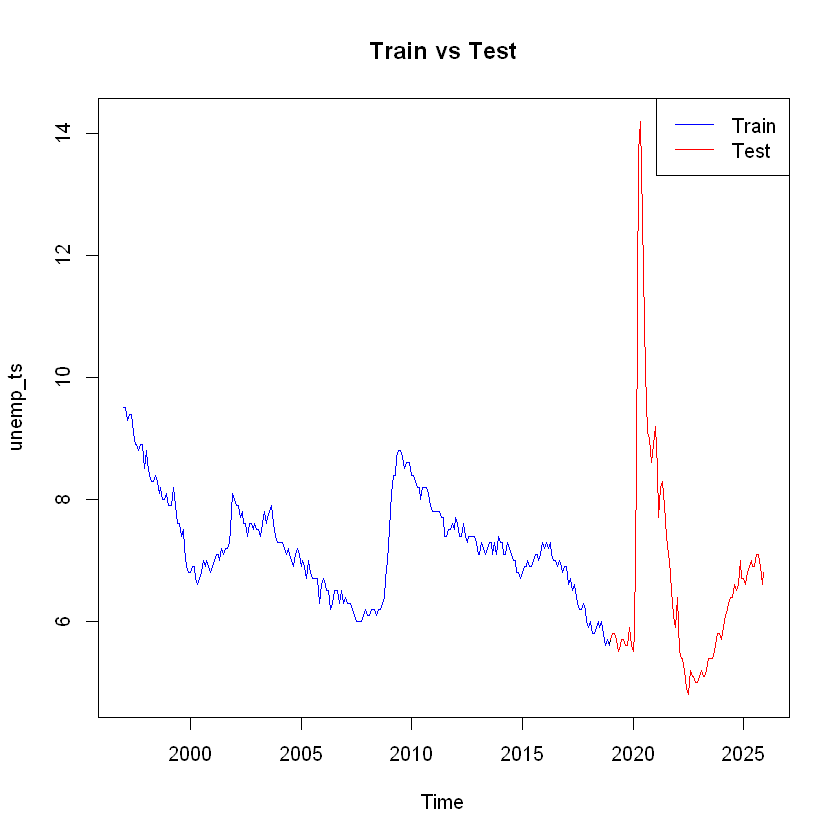

In [95]:
plot(unemp_ts, col="black", main="Train vs Test")
lines(unemp_train, col="blue")
lines(unemp_test, col="red")
legend("topright", legend=c("Train","Test"), col=c("blue","red"), lty=1)

In [ ]:
par(mfrow = c(1, 2))

plot(xreg_ts[, "log_gdp"], col = "black", main = "log_gdp: Train vs Test", ylab = "log_gdp")
lines(xreg_train[, "log_gdp"], col = "blue", lwd = 2)
lines(xreg_test[, "log_gdp"], col = "red", lwd = 2)
legend("topleft", legend = c("Train", "Test"), col = c("blue", "red"), lty = 1, lwd = 2)

plot(xreg_ts[, "total_"], col = "black", main = "Employment: Train vs Test", ylab = "diff_emp")
lines(xreg_train[, "diff_emp"], col = "blue", lwd = 2)
lines(xreg_test[, "diff_emp"], col = "red", lwd = 2)
legend("topleft", legend = c("Train", "Test"), col = c("blue", "red"), lty = 1, lwd = 2)


ERROR: Error in `[.default`(xreg_ts, , "log_gdp"): incorrect number of dimensions


In [98]:
armax_model_auto  <- auto.arima(unemp_train, xreg = xreg_train,
                           seasonal = TRUE,
                           stepwise = FALSE,
                           approximation = FALSE)

summary(armax_model_auto)

Series: unemp_train 
Regression with ARIMA(0,1,1)(0,0,2)[12] errors 

Coefficients:
          ma1     sma1     sma2   drift      xreg
      -0.1197  -0.3453  -0.1070  0.0230  -17.3906
s.e.   0.0649   0.0640   0.0609  0.0065    2.4895

sigma^2 = 0.01855:  log likelihood = 154.33
AIC=-296.67   AICc=-296.34   BIC=-275.24

Training set error measures:
                        ME      RMSE       MAE         MPE     MAPE      MASE
Training set -0.0002100046 0.1346365 0.1047598 -0.04371199 1.442263 0.2041722
                    ACF1
Training set 0.003474615

In [99]:
armax_fc_auto <- forecast(armax_model_auto, xreg = xreg_test)


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.0002100046,0.1346365,0.1047598,-0.04371199,1.442263,0.2041722,0.003474615,NA
Test set,0.7386363216,1.4952357,0.9964941,7.72621210,12.727591,1.9421231,0.923733039,1.732153


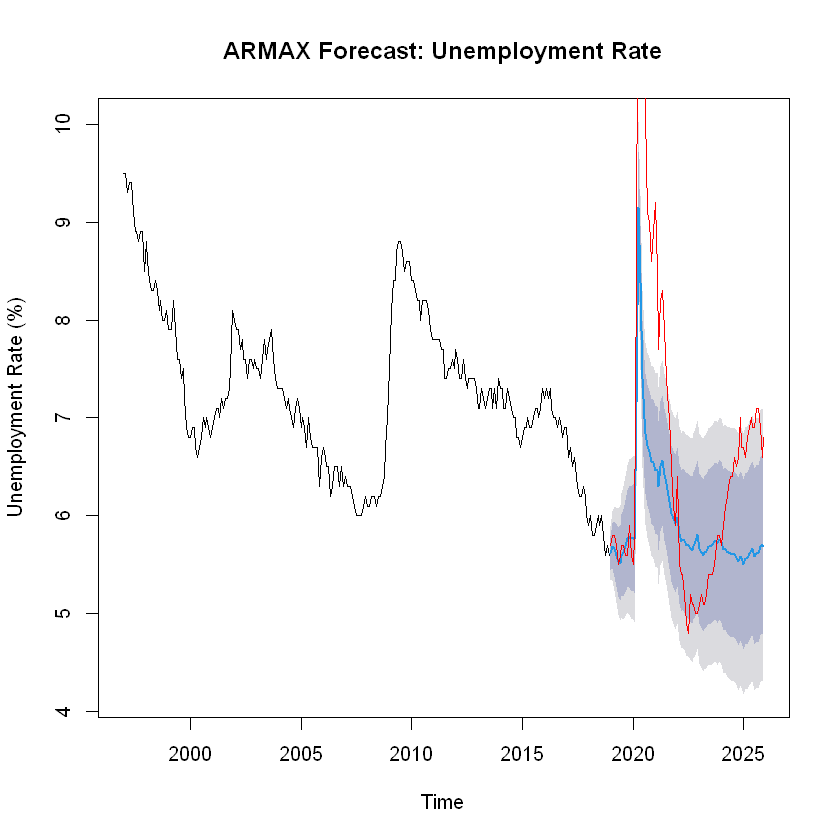

In [100]:
plot(armax_fc_auto,
     main = "ARMAX Forecast: Unemployment Rate",
     ylab = "Unemployment Rate (%)",
     xlab = "Time")

lines(unemp_test, col = "red")
accuracy(armax_fc_auto, unemp_test)


	Ljung-Box test

data:  Residuals from Regression with ARIMA(0,1,1)(0,0,2)[12] errors
Q* = 16.643, df = 21, p-value = 0.7325

Model df: 3.   Total lags used: 24




	Box-Ljung test

data:  residuals(armax_model_auto)
X-squared = 15.953, df = 20, p-value = 0.7195


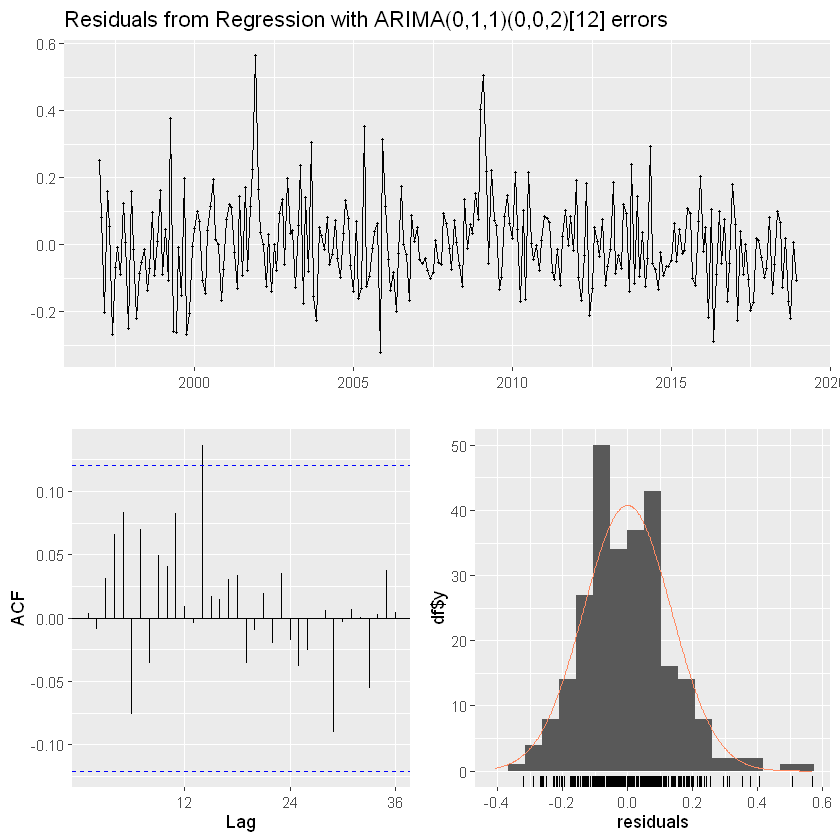

In [101]:
checkresiduals(armax_fc_auto)
Box.test(residuals(armax_model_auto), lag = 20, type = "Ljung-Box")

Since our p-value for the auto fitted ARMAX model is 0.7325 > 0.05, show our model has captured most mathematical patterns in the data. This is also apparent as our residuals are mostly random noise (except for a few large spikes).

Like this ARIMA model, the ARMAX model too failed to perform well for the large spike during 2020, but the 95% confidence interval usually captures the true value of unemployment percentage.